In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import MultinomialNB

In [ ]:
df  = pd.read_csv("/content/drive/MyDrive/spam mail.csv")
df

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df = df[['Category', 'Masseges']]
df.columns = df.columns.str.strip()

print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Category                                           Masseges
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


# EDA

In [ ]:
df.shape

(5572, 2)

In [ ]:
df.columns.tolist()

['Category', 'Masseges']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.isnull().sum()

,0
Category,0
Masseges,0


In [ ]:
df.describe()

,Category,Masseges
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


# **DATA VISUALIZATION**

Bar Chart

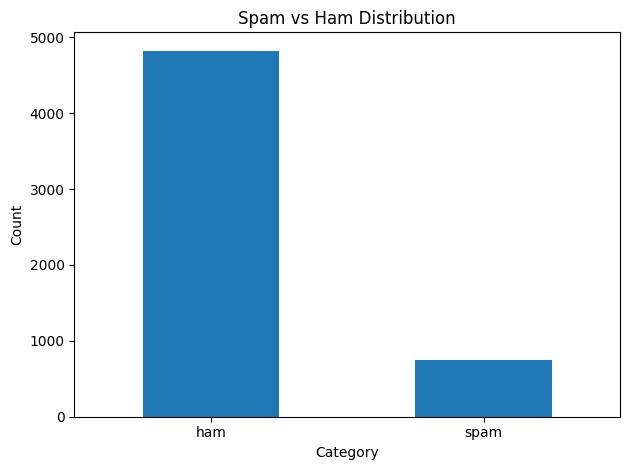

In [ ]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Message length distribution

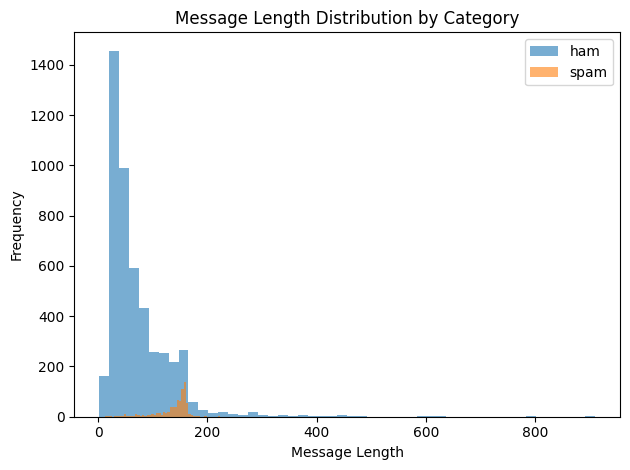

In [ ]:
df['msg_length'] = df['Masseges'].apply(len)
df.groupby('Category')['msg_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.title("Message Length Distribution by Category")
plt.xlabel("Message Length")
plt.tight_layout()
plt.show()

Boxplot

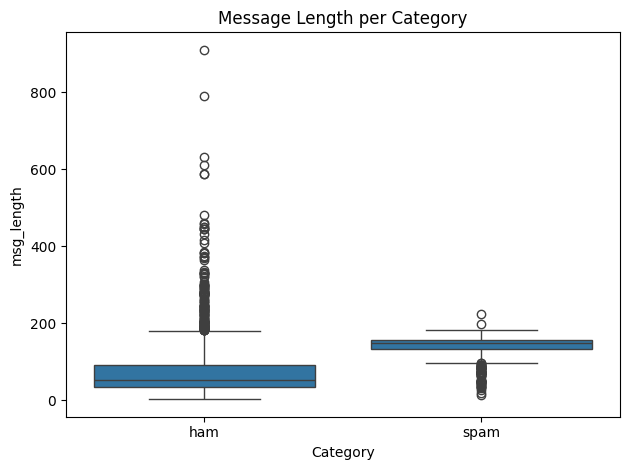

In [ ]:
sns.boxplot(x='Category', y='msg_length', data=df)
plt.title("Message Length per Category")
plt.tight_layout()
plt.show()

 Word count distribution

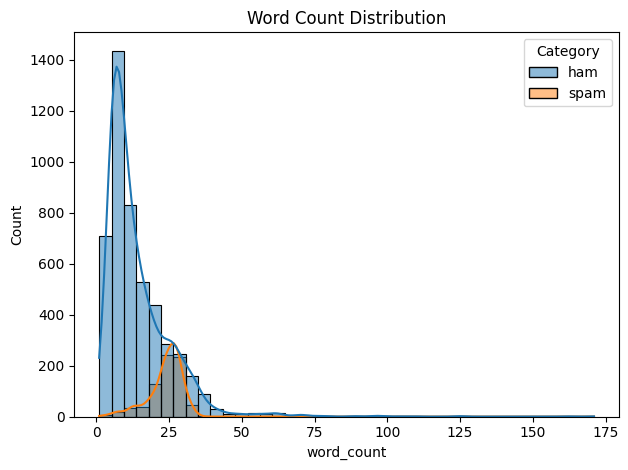

In [ ]:
df['word_count'] = df['Masseges'].apply(lambda x: len(x.split()))
sns.histplot(data=df, x='word_count', hue='Category', bins=40, kde=True)
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()

OUTLIER

In [ ]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column} Outliers: {outliers.shape[0]}")
    return outliers, lower_bound, upper_bound

# Detect outliers
out_len, lb_len, ub_len = detect_outliers_iqr(df, 'msg_length')
out_word, lb_word, ub_word = detect_outliers_iqr(df, 'word_count')

msg_length Outliers: 68
word_count Outliers: 71


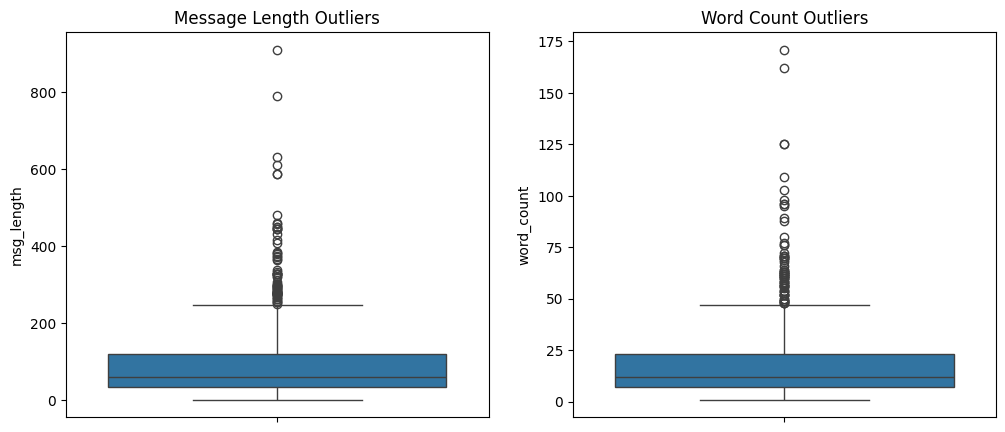

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['msg_length'])
plt.title("Message Length Outliers")

plt.subplot(1,2,2)
sns.boxplot(y=df['word_count'])
plt.title("Word Count Outliers")

plt.show()

In [ ]:
# Remove outliers based on both columns
df_clean = df[
    (df['msg_length'] >= lb_len) & (df['msg_length'] <= ub_len) &
    (df['word_count'] >= lb_word) & (df['word_count'] <= ub_word)
]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (5572, 4)
After removing outliers: (5496, 4)


# **DATA PREPROCESSING**

Handle missing values

In [ ]:
df['Masseges'].fillna('', inplace=True)
df['Category'].fillna(df['Category'].mode()[0], inplace=True)

/tmp/ipykernel_4776/820543996.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Masseges'].fillna('', inplace=True)
/tmp/ipykernel_4776/820543996.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

Encode target variable: ham=0, spam=1

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])   # ham→0, spam→1

print("\nEncoded Labels:\n", df[['Category', 'label']].drop_duplicates())


Encoded Labels:
   Category  label
0      ham      0
2     spam      1


FEATURE SELECTION & TARGET

In [ ]:
X_raw = df['Masseges']
y = df['label']

TRAIN-TEST SPLIT


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size    :", X_test.shape[0])

Training set size: 4457
Test set size    : 1115


MODEL TRAINING & EVALUATION

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Parameter grid
param_grid_lr = {
    'C': [0.1, 1, 5, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

# Best model
best_lr = grid_lr.best_estimator_

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
from sklearn.naive_bayes import MultinomialNB

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy'
)

grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_

print("Best NB Params:", grid_nb.best_params_)

Best NB Params: {'alpha': 0.1}


In [ ]:
# import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#empty list to store result
results = []
for name, model in models.items():
    #train model
    model.fit(X_train, y_train)
    # prediction
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    #append results
    results.append([name, acc, prec, rec, f1])

In [ ]:
# create data frame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
# Display
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.961435   1.000000  0.711409  0.831373
1        Decision Tree  0.964126   0.881119  0.845638  0.863014
2        Random Forest  0.973094   1.000000  0.798658  0.888060
3                  SVM  0.978475   0.992126  0.845638  0.913043
4                  KNN  0.913901   1.000000  0.355705  0.524752


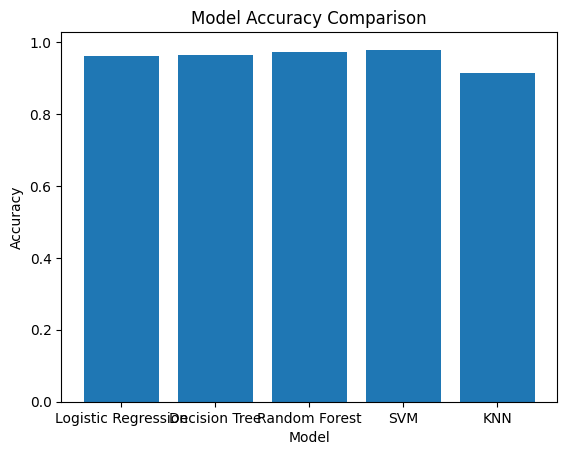

In [ ]:
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

MODEL COMPARISON

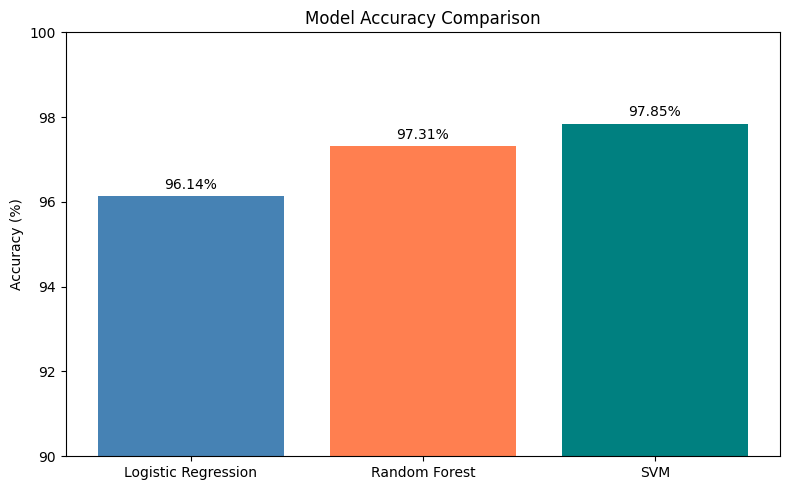

In [ ]:
acc_lr = results_df[results_df['Model'] == 'Logistic Regression']['Accuracy'].iloc[0]
acc_rf = results_df[results_df['Model'] == 'Random Forest']['Accuracy'].iloc[0]
acc_svm = results_df[results_df['Model'] == 'SVM']['Accuracy'].iloc[0]

models      = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies  = [acc_lr,acc_rf, acc_svm]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, [a * 100 for a in accuracies], color=['steelblue','coral','teal','orange'])
plt.ylim(90, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{acc*100:.2f}%", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

CONFUSION MATRIX (Best Model)

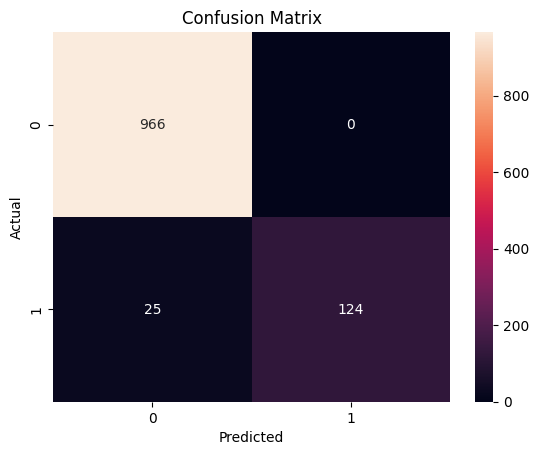

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Re-train Random Forest model and get predictions for pred_rf
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

PREDICT ON NEW MESSAGE

In [ ]:
def predict_spam(message):
    vec = tfidf.transform([message])
    result = LogisticRegression(max_iter=1000).fit(X_train, y_train).predict(vec)
    # Re-use already-fitted model instead:
    # result = lr_model.predict(vec)
    label = le.inverse_transform(result)[0]
    return label

Example usage

In [ ]:
sample = "Congratulations! You've won a FREE iPhone. Click now to claim your prize!"
print("Sample message:", sample)
print("Prediction    :", predict_spam(sample))

Sample message: Congratulations! You've won a FREE iPhone. Click now to claim your prize!
Prediction    : spam


In [ ]:
import pickle

# Assuming model_rf (Random Forest) is the desired best model to save.
# model_rf was trained and evaluated earlier in the notebook.
best_model = model_rf

# It's crucial to save the TF-IDF vectorizer along with the model
# to properly preprocess new messages for prediction.
pickle.dump(best_model, open('spam_detector_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

In [ ]:
import gradio as gr
import pickle

# Load saved model and vectorizer
with open('spam_detector_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

# Prediction function
def predict_spam(message):
    if message.strip() == "":
        return "⚠️ Please enter a message"

    vec = tfidf.transform([message])
    prediction = model.predict(vec)[0]

    if prediction == 1:
        return "🚨 Spam Message"
    else:
        return "✅ Not Spam (Ham)"

# Clear function
def clear_text():
    return ""

# GUI Design
with gr.Blocks(title="Spam Detection System") as demo:

    gr.Markdown("# 📩 Spam Detection System")
    gr.Markdown("Enter a message to check whether it is **Spam or Ham**.")

    with gr.Row():
        input_text = gr.Textbox(
            lines=5,
            placeholder="Type your message here...",
            label="Message"
        )

    with gr.Row():
        output_text = gr.Textbox(label="Prediction")

    with gr.Row():
        btn_predict = gr.Button("🔍 Check")
        btn_clear = gr.Button("🧹 Clear")

    # Button actions
    btn_predict.click(predict_spam, inputs=input_text, outputs=output_text)
    btn_clear.click(clear_text, outputs=input_text)

# Launch app
if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf2481d005fff339cf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
